# 对于宁外表白墙特定时间段内发帖样本的数据分析

## 摘要
本项目以宁波外国语学校表白墙QQ空间（账号：2087338463）在 2022 年 5 月 30 日至 2026 年 4 月 4 日期间的投稿图片为数据源，通过OCR文字识别、大语言模型特征提取、结构化数据整理的流程，构建了包含发帖目的、匿名状态、情感倾向、班级部门等维度的数据集。本文档基于该数据集，利用 Python（Pandas、Matplotlib 等）进行数据清洗、统计分析与可视化，旨在挖掘校园社交行为的基本特征与潜在规律。

## 数据处理流程
1. **数据下载**  
   使用 [QQ空间导出助手](https://github.com/ShunCai/QZoneExport) 抓取目标时间段内的表白墙QQ空间图片。
2. **OCR 文字识别与清洗**  
   采用 [PaddleOCR](https://github.com/PaddlePaddle/PaddleOCR) 识别图片中的文本，并通过 Python 脚本去除噪声、纠正明显错误，输出待分析的原始语料。
3. **语义特征提取**  
   调用 [硅基流动](https://cloud.siliconflow.cn/) 上的 DeepSeek-V4-Flash 大语言模型，对清洗后的文本进行多帖子分割和语义理解，提取发帖人/目标对象的班级、部门、匿名状态、发帖目的、情感倾向等特征，整理为 CSV 格式。
4. **数据分析与可视化**  
   使用 Pandas 等工具对提取后的结构化数据进行统计描述、交叉分析和可视化，回答研究问题。

## 数据概览
- **时间范围**：2022.05.30 - 2026.04.04  
- **原始图片量**：1,860 张
- **有效图片数**：1,761 张  
- **提取帖子数**：1,739 条  
- **主要字段**：image_id, post_id, date, author_class, author_department, is_anonymous, purpose, target_class, target_department, description, sentiment, post_text

## 局限性分析
本项目完全由本人单独进行，存在以下显然的局限性
- 本项目的脚本部分由AI工具（DeepSeek V3.2, DeepSeek V4 Pro, Gemini 3.1 Pro）编写。由于个人水平有限，存在**项目结构不规范**，**代码稳健型差**，**代码可读性差**，**项目可迁移能力弱**等问题。
- 由于OCR识别工具与Jupyter Notebook所需环境存在冲突，数据清洗与数据分析工作在不同环境中进行。
- 特征提取由大语言模型完成，可能存在误判（如匿名状态识别错误、目的分类偏差）。由于缺少人工标注，目前无法精确量化准确率。
- 数据仅来自某一校园表白墙、跨度约 4 年，样本量较小且可能存在个别图片 OCR 失败、帖子遗漏的情况，统计分析不具有现实参考价值。


**本项目的任何公开版本均对所有敏感个人信息脱敏处理，报告仅呈现群体统计结果。**


---
## 数据分析部分

### 1.初始化

#### 1.1 工具包初始化

In [26]:
from pathlib import Path
import os

import re

import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['font.family'] = 'HarmonyOS Sans SC'
plt.rcParams['axes.unicode_minus'] = False

import pandas as pd
pd.plotting.register_matplotlib_converters()

import seaborn as sns
from pypinyin import pinyin, Style
from wordcloud import WordCloud # type: ignore

print("Library Initiated")

Library Initiated


#### 1.2 文件初始化

In [27]:
BASE_DIR = Path(os.getcwd())
input_path = BASE_DIR / "input"
output_dir = BASE_DIR / "output"

full_data: pd.DataFrame = pd.read_csv(
    input_path / "extracted_posts_v2_public.csv", parse_dates=["date"], index_col="post_id"
)

if "post_text" in full_data.columns:
    full_data.drop("post_text", axis="columns", inplace=True)

display(full_data.head(5))
print("File initiated")

,image_id,date,author_class,author_department,is_anonymous,purpose,target_class,target_department,description,sentiment,target_name_initial
post_id,,,,,,,,,,,
0001_01,1,2026-04-04,NaN,NaN,True,表白,I2601,I,学生物,积极,lxj
0002_01,2,2026-04-04,NaN,NaN,True,寻人,S2802,S,帅 有气质,积极,hwx
0003_01,3,2026-04-04,NaN,NaN,True,寻人,NaN,I,高二国际部,中性,lqx
0004_01,4,2026-02-17,NaN,NaN,True,寻人,NaN,NaN,NaN,中性,xzm
0006_01,6,2026-02-04,GTE94,NaN,True,寻人,S2704,S,NaN,中性,zg


File initiated


### 2. 数据处理
引入部分新特征，对部分老特征进行修正，填充部分缺失值

#### 2.1 整理 Department部门 字段
应当为I S J中任意一个，其余任何值都不合法

In [28]:
display(full_data["author_department"].value_counts())
display(full_data["target_department"].value_counts())

author_department
J    112
S     37
I     22
Name: count, dtype: int64

target_department
J        374
S        151
I         89
J J       11
I I        4
J J J      2
S S        1
I I I      1
Name: count, dtype: int64

target_department字段有一些奇奇怪怪的值

In [29]:
mask = full_data["target_department"].str.match(r"[\w ]{2,}", na=False)
full_data.loc[mask, "target_department"] = (
    full_data.loc[mask, "target_department"].str.split().str[0]
)

display(full_data["target_department"].value_counts())

target_department
J    387
S    152
I     94
Name: count, dtype: int64

#### 2.2 构建name_initial字段（姓名首字母）

消去被识别为“学长学姐”的名字

In [30]:
if "target_name" in full_data.columns:
    full_data.loc[full_data["target_name"] == "学长学姐", "target_name"] = None

full_data.loc[full_data.target_name_initial == "xzxj", "target_name_initial"] = None

转化首字母

In [31]:
eng_pattern = re.compile("\\w+", re.ASCII)


def to_name_initial(name: str) -> str:
    if eng_pattern.fullmatch(name):
        return name
    else:
        initials = pinyin(name, style=Style.FIRST_LETTER)
        return "".join([item[0] for item in initials])

if "target_name" in full_data.columns:
    mask = full_data["target_name"].notnull()
    full_data.loc[mask, "target_name_initial"] = full_data.loc[mask, "target_name"].map(
        to_name_initial
    )

In [32]:
display(full_data.head(3))

,image_id,date,author_class,author_department,is_anonymous,purpose,target_class,target_department,description,sentiment,target_name_initial
post_id,,,,,,,,,,,
0001_01,1,2026-04-04,NaN,NaN,True,表白,I2601,I,学生物,积极,lxj
0002_01,2,2026-04-04,NaN,NaN,True,寻人,S2802,S,帅 有气质,积极,hwx
0003_01,3,2026-04-04,NaN,NaN,True,寻人,NaN,I,高二国际部,中性,lqx


In [33]:
full_data.target_name_initial.value_counts()

target_name_initial
hys       13
lry        9
jx         8
t          7
sm         6
          ..
dzx        1
qj lsq     1
czx        1
xkx        1
lyp        1
Name: count, Length: 569, dtype: int64

In [34]:
full_data[
    full_data.target_name_initial
    == full_data.target_name_initial.value_counts().idxmax()
].head(5)

,image_id,date,author_class,author_department,is_anonymous,purpose,target_class,target_department,description,sentiment,target_name_initial
post_id,,,,,,,,,,,
0055_01,55,2024-12-05,NaN,NaN,False,表白,S2703,S,美 抑郁症的克星 植物人的闹钟 帅,积极,hys
0415_01,415,2023-06-11,NaN,NaN,True,表白,J2402,J,温柔 有礼貌 好看 皮肤白 喜欢戴发卡,积极,hys
0434_01,434,2023-06-11,NaN,NaN,True,表白,J2402,J,人真的很好,积极,hys
0439_01,439,2023-06-03,NaN,NaN,True,表白,J2402,J,性格开朗 有分寸 有边界感,积极,hys
0442_01,442,2023-06-03,NaN,NaN,True,表白,J2402,J,好美,积极,hys


#### 2.3 修正班级格式
只保留班级格式为\\w\\d{4}的数据

In [35]:
full_data.loc[~full_data["target_class"].str.match("\\w\\d{4}"), "target_class"] = None

In [36]:
full_data.loc[~full_data["author_class"].str.match("\\w\\d{4}"), "author_class"] = None

#### 2.4 填充空数据

In [37]:
# 姓名 —— 未知的记为 "Anonymous"
if "target_name" in full_data.columns:
    full_data[["author_name", "target_name"]] = full_data[
        ["author_name", "target_name"]
    ].fillna("Anonymous")

# 目标姓名缩写 —— 没有缩写的填 "notexist"
full_data[["target_name_initial"]] = full_data[["target_name_initial"]].fillna(
    "notexist"
)

# 部门 —— 未知部门填 "U"
full_data[["author_department", "target_department"]] = full_data[
    ["author_department", "target_department"]
].fillna("U")

# 班级 —— 未知班级填 "U0000"
full_data[["author_class", "target_class"]] = full_data[
    ["author_class", "target_class"]
].fillna("U0000")

# 描述 —— 无描述填 "无"
full_data["description"] = full_data["description"].fillna("无")

# 目的
full_data["purpose"] = full_data["purpose"].fillna("其他")

再看一下数据

In [38]:
full_data.info()

<class 'pandas.DataFrame'>
Index: 1739 entries, 0001_01 to 1858_01
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   image_id             1739 non-null   int64         
 1   date                 1739 non-null   datetime64[us]
 2   author_class         1739 non-null   str           
 3   author_department    1739 non-null   str           
 4   is_anonymous         1739 non-null   bool          
 5   purpose              1739 non-null   str           
 6   target_class         1739 non-null   str           
 7   target_department    1739 non-null   str           
 8   description          1739 non-null   str           
 9   sentiment            1739 non-null   str           
 10  target_name_initial  1739 non-null   str           
dtypes: bool(1), datetime64[us](1), int64(1), str(8)
memory usage: 215.7+ KB


### 3. 数据分析与可视化

#### 3.1 发帖目的可视化

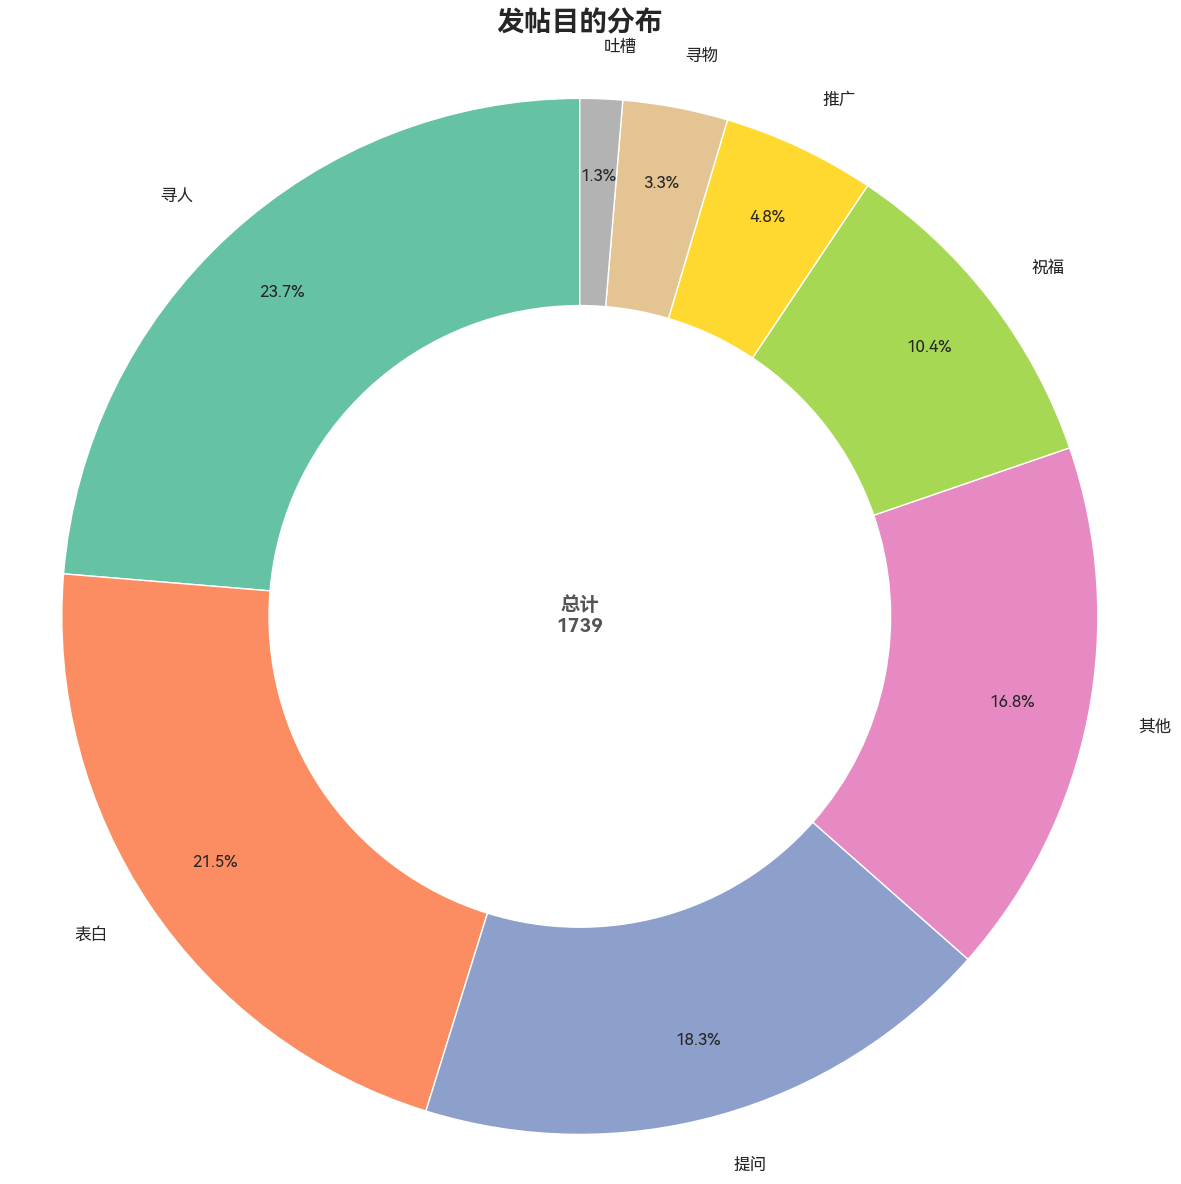

In [46]:
purpose_counts = full_data['purpose'].value_counts()
colors = sns.color_palette('Set2', n_colors=len(purpose_counts))

plt.figure(figsize=(12, 12))

# 绘制甜甜圈图
plt.pie(
    purpose_counts, 
    labels=purpose_counts.index, # type:ignore
    autopct='%1.1f%%',
    startangle=90, 
    colors=colors, 
    pctdistance=0.85,
    textprops={'fontsize': 12},
    wedgeprops={'width': 0.4, 'edgecolor': 'white'} # width参数控制空心大小
)

# 在中间添加总数或标题
plt.text(0, 0, '总计\n{}'.format(purpose_counts.sum()), 
         ha='center', va='center', fontsize=14, fontweight='bold', color='#555555')

plt.title('发帖目的分布', fontsize=20, pad=20, fontweight="bold")
plt.axis('equal')
plt.tight_layout()
plt.savefig(output_dir / "post_purpose.png")
plt.show()

#### 3.2 根据时间趋势统计帖子数量

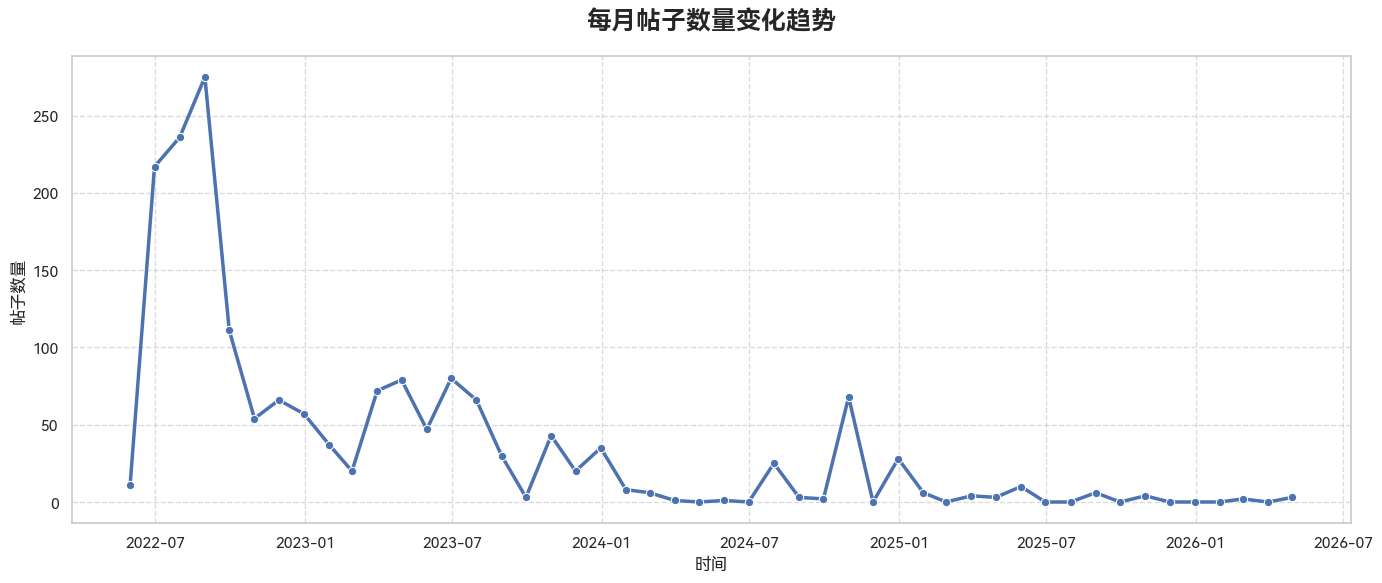

In [ ]:
full_data["date_dt"] = pd.to_datetime(full_data["date"])
monthly = full_data.set_index("date_dt").resample("ME").size()

plt.figure(figsize=(14, 6)) # 稍微拉宽一点

ax = sns.lineplot(
    x=monthly.index, 
    y=monthly.values, 
    marker="o", 
    linewidth=2.5, 
    markersize=6,
    color="#4c72b0" # 使用一种稳重的蓝色
)

plt.title("每月帖子数量变化趋势", fontsize=20, pad=20, fontweight="bold") # 标题加粗，加大间距
plt.xlabel("时间", fontsize=12)
plt.ylabel("帖子数量", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.7) # 虚线网格，透明度适中

plt.tight_layout() # 自动调整布局防止标签被遮挡
# plt.savefig(output_dir / "post#_change_beautified.png")
plt.show()

#### 3.3 各学部/班级活跃情况

##### 3.3.1 各学部活跃情况

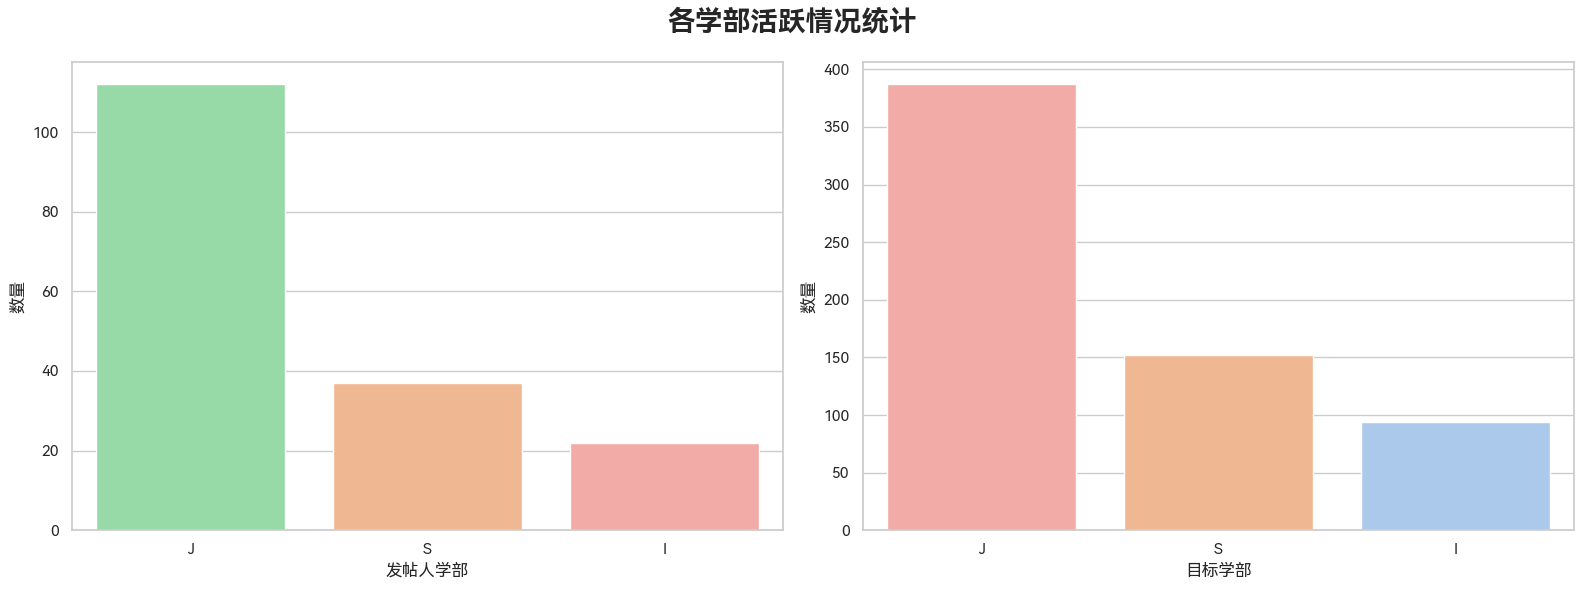

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 发帖人学部
sns.countplot(
    data=full_data,
    x="author_department",
    order=["J", "S", "I"],
    hue="author_department",
    palette="pastel",
    ax=axes[0],
)
axes[0].set_xlabel("发帖人学部")
axes[0].set_ylabel("数量")

# 目标学部
sns.countplot(
    data=full_data,
    x="target_department",
    order=["J", "S", "I"],
    hue="target_department",
    palette="pastel",
    ax=axes[1],
)
axes[1].set_xlabel("目标学部")
axes[1].set_ylabel("数量")

plt.suptitle("各学部活跃情况统计", fontsize=20, fontweight="bold")

plt.tight_layout()
plt.savefig(output_dir / "dept_distribution.png")
plt.show()

##### 3.3.2 各班级活跃情况

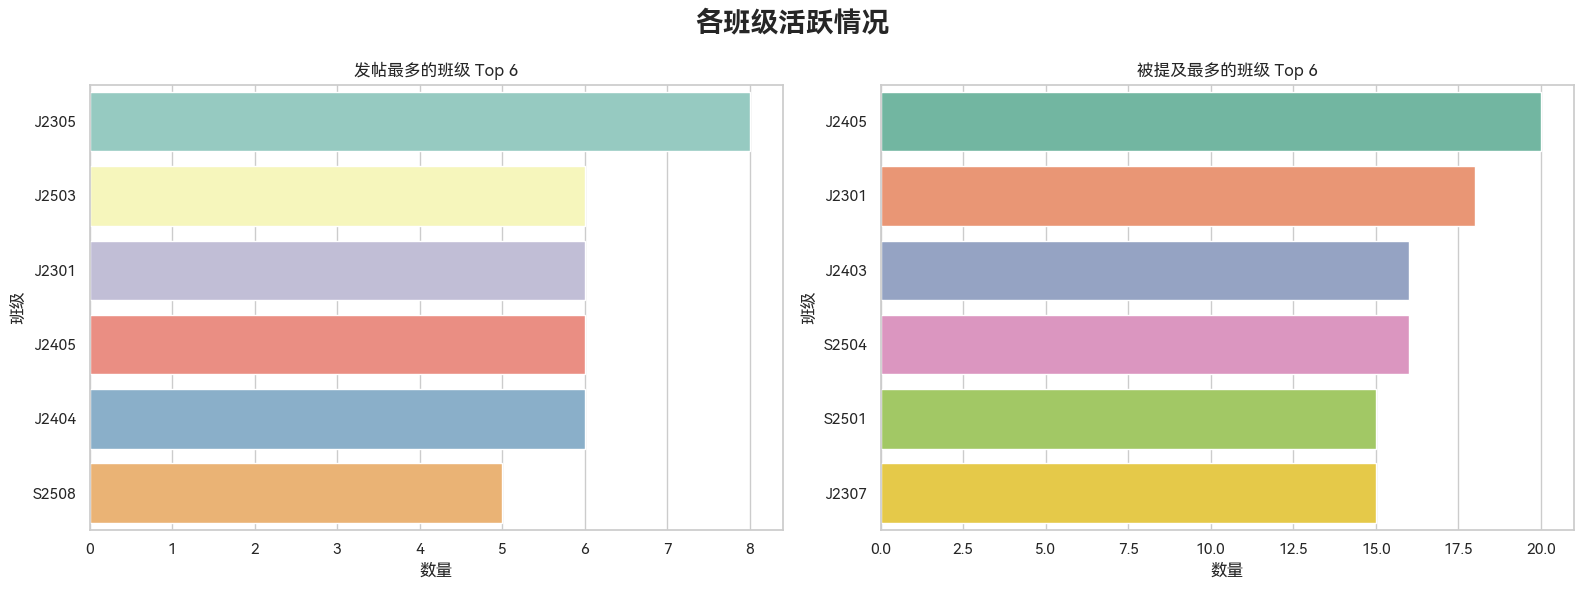

In [48]:
# 过滤未知班级
class_valid = full_data[full_data["author_class"] != "U0000"]["author_class"]
top_author_classes = class_valid.value_counts().head(6)

target_valid = full_data[full_data["target_class"] != "U0000"]["target_class"]
top_target_classes = target_valid.value_counts().head(6)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    x=top_author_classes.values,
    y=top_author_classes.index,
    ax=axes[0],
    hue=top_author_classes.index,
    palette="Set3",
    legend=False,
)
axes[0].set_title("发帖最多的班级 Top 6")
axes[0].set_xlabel("数量")
axes[0].set_ylabel("班级")

sns.barplot(
    x=top_target_classes.values,
    y=top_target_classes.index,
    ax=axes[1],
    hue=top_target_classes.index,
    palette="Set2",
    legend=False,
)
axes[1].set_title("被提及最多的班级 Top 6")
axes[1].set_xlabel("数量")
axes[1].set_ylabel("班级")

plt.suptitle("各班级活跃情况", fontsize=20, fontweight="bold")

plt.tight_layout()
plt.savefig(output_dir / "active_class.png")
plt.show()

#### 3.4 匿名与否与目的的关联

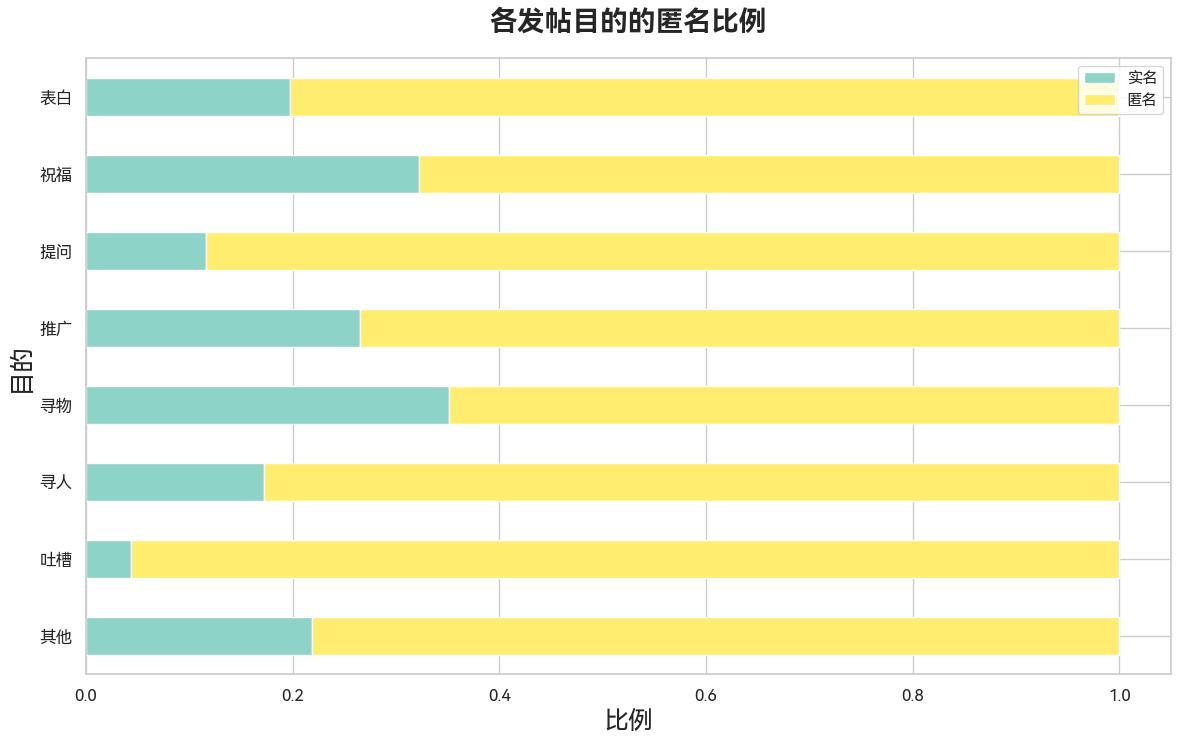

In [49]:
# 匿名 vs 目的
anon_purpose = pd.crosstab(
    full_data["purpose"], full_data["is_anonymous"], normalize="index"
)
anon_purpose.plot(kind="barh", stacked=True, figsize=(14, 8), colormap="Set3")
plt.title("各发帖目的的匿名比例", fontsize=20, pad=20, fontweight="bold")
plt.xlabel("比例", fontsize=18)
plt.ylabel("目的", fontsize=18)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(labels=["实名", "匿名"])
plt.savefig(output_dir / "purpose_anonymous_proportion.png", bbox_inches="tight")
plt.show()

#### 3.5 热门分析

##### 3.5.1 热门对象分析
终于到这个环节了

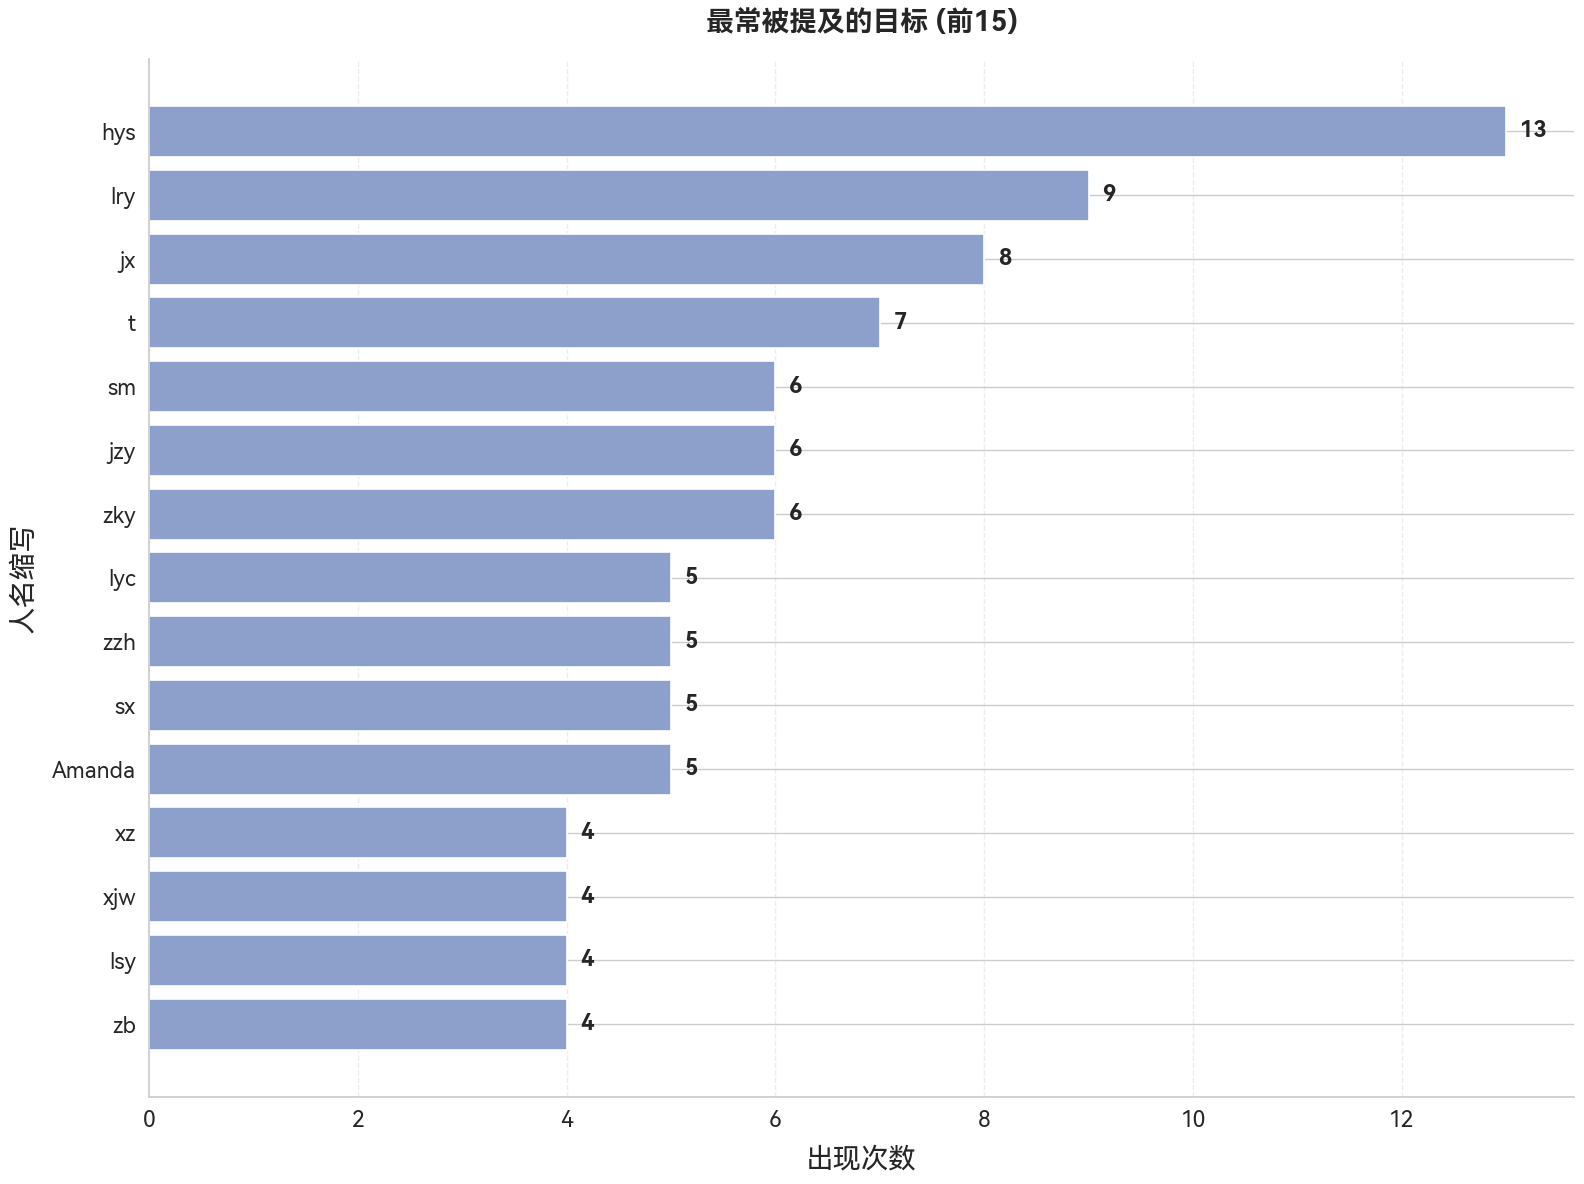

In [50]:
top_n = 15
top_names = full_data["target_name_initial"].value_counts()
# 排除无效占位符
top_names = top_names[~top_names.index.isin(["notexist", "Anonymous"])]
top_names = top_names.head(top_n)

# 从 Set2 调色板中选一个颜色（这里用第一个，你可以换成 [1] [2] 等）
color = sns.color_palette("Set2")[2]

plt.figure(figsize=(16, 12))
bars = plt.barh(
    top_names.index,
    top_names.values,  # type: ignore
    color=color,
    edgecolor="white",
    linewidth=1.2,
)

# 最高频在顶部
plt.gca().invert_yaxis()

# 数值标签
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + max(top_names.values) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width)}",
        va="center",
        ha="left",
        fontsize=16,
        fontweight="bold",
    )

plt.title(f"最常被提及的目标 (前{len(top_names)})", fontsize=20, pad=20, fontweight="bold")
plt.xlabel("出现次数", fontsize=20, labelpad=10)
plt.ylabel("人名缩写", fontsize=20, labelpad=10)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# 去掉上、右脊柱，保留下、左并弱化颜色
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#CCCCCC")
ax.spines["bottom"].set_color("#CCCCCC")

# 网格只保留垂直方向（现在由 whitegrid 提供，可只显示竖线）
ax.grid(axis="x", linestyle="--", alpha=0.5, color="#DDDDDD")

plt.tight_layout()
plt.savefig(output_dir / "target_total.png")
plt.show()

##### 3.5.2 分部门热门对象分析

<Figure size 1800x1000 with 0 Axes>

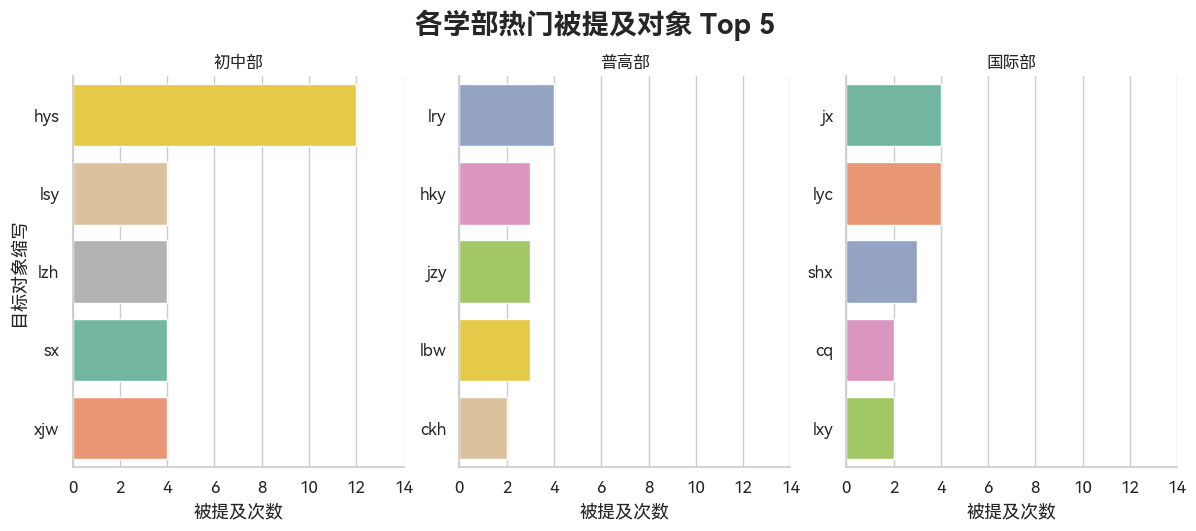

In [52]:
# 1. 过滤无效部门和姓名
valid_dept = ["I", "S", "J"]
temp_df = full_data[
    full_data["target_department"].isin(valid_dept)
    & ~full_data["target_name_initial"].isin(["notexist", "Anonymous"])
].copy()

# 2. 统计每个部门、每个目标出现的次数
dept_name_counts = (
    temp_df.groupby(["target_department", "target_name_initial"])
    .size()
    .reset_index(name="count")
)

# 3. 每个部门内取前 5 名（用排序 + groupby.head，保留所有列）
top5_per_dept = (
    dept_name_counts.sort_values(
        ["target_department", "count"], ascending=[True, False]
    )
    .groupby("target_department")
    .head(5)
    .reset_index(drop=True)
)

# 4. 添加中文部门名
dept_cn_map = {"I": "国际部", "S": "普高部", "J": "初中部"}
top5_per_dept["department_cn"] = top5_per_dept["target_department"].map(dept_cn_map)

# 5. 绘图
plt.figure(figsize=(18, 10))
g = sns.catplot(
    data=top5_per_dept,
    y="target_name_initial",
    x="count",
    col="department_cn",
    kind="bar",
    hue="target_name_initial",
    palette="Set2",
    sharey=False,
    col_order=["初中部", "普高部", "国际部"],
    height=5,
    aspect=0.8,
)
g.set_titles("{col_name}")
g.set_axis_labels("被提及次数", "目标对象缩写", fontsize=13)
g.figure.suptitle("各学部热门被提及对象 Top 5", fontsize=20, y=1.05, fontweight="bold")
g.set_xticklabels(fontsize=12)
g.set_yticklabels(fontsize=12)
plt.savefig(output_dir / "target_dept.png", bbox_inches="tight")
plt.show()

#### 3.6 词云分析

##### 3.6.1 总览

In [55]:
def generate_word_cloud(text: str, title: str, save_name: str):
    # 配置词云
    wc = WordCloud(
        font_path="/usr/local/share/fonts/HarmonyOS_Sans/HarmonyOS_Sans_SC_Regular.ttf",
        width=3000,
        height=1800,
        background_color="white",
        collocations=False,
    ).generate(text)

    # 设置 dpi，让 figsize 与词云像素严格对应
    dpi = 300
    fig = plt.figure(figsize=(3000 / dpi, 1800 / dpi), dpi=dpi)
    plt.title(title, fontsize=24, fontweight="bold", pad=8)

    # 显示词云（不显示坐标轴）
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.tight_layout()

    # 保存图片
    plt.savefig(
        output_dir / (save_name + ".png"), dpi=dpi, pad_inches=0
    )

    # 显示图形
    plt.show()

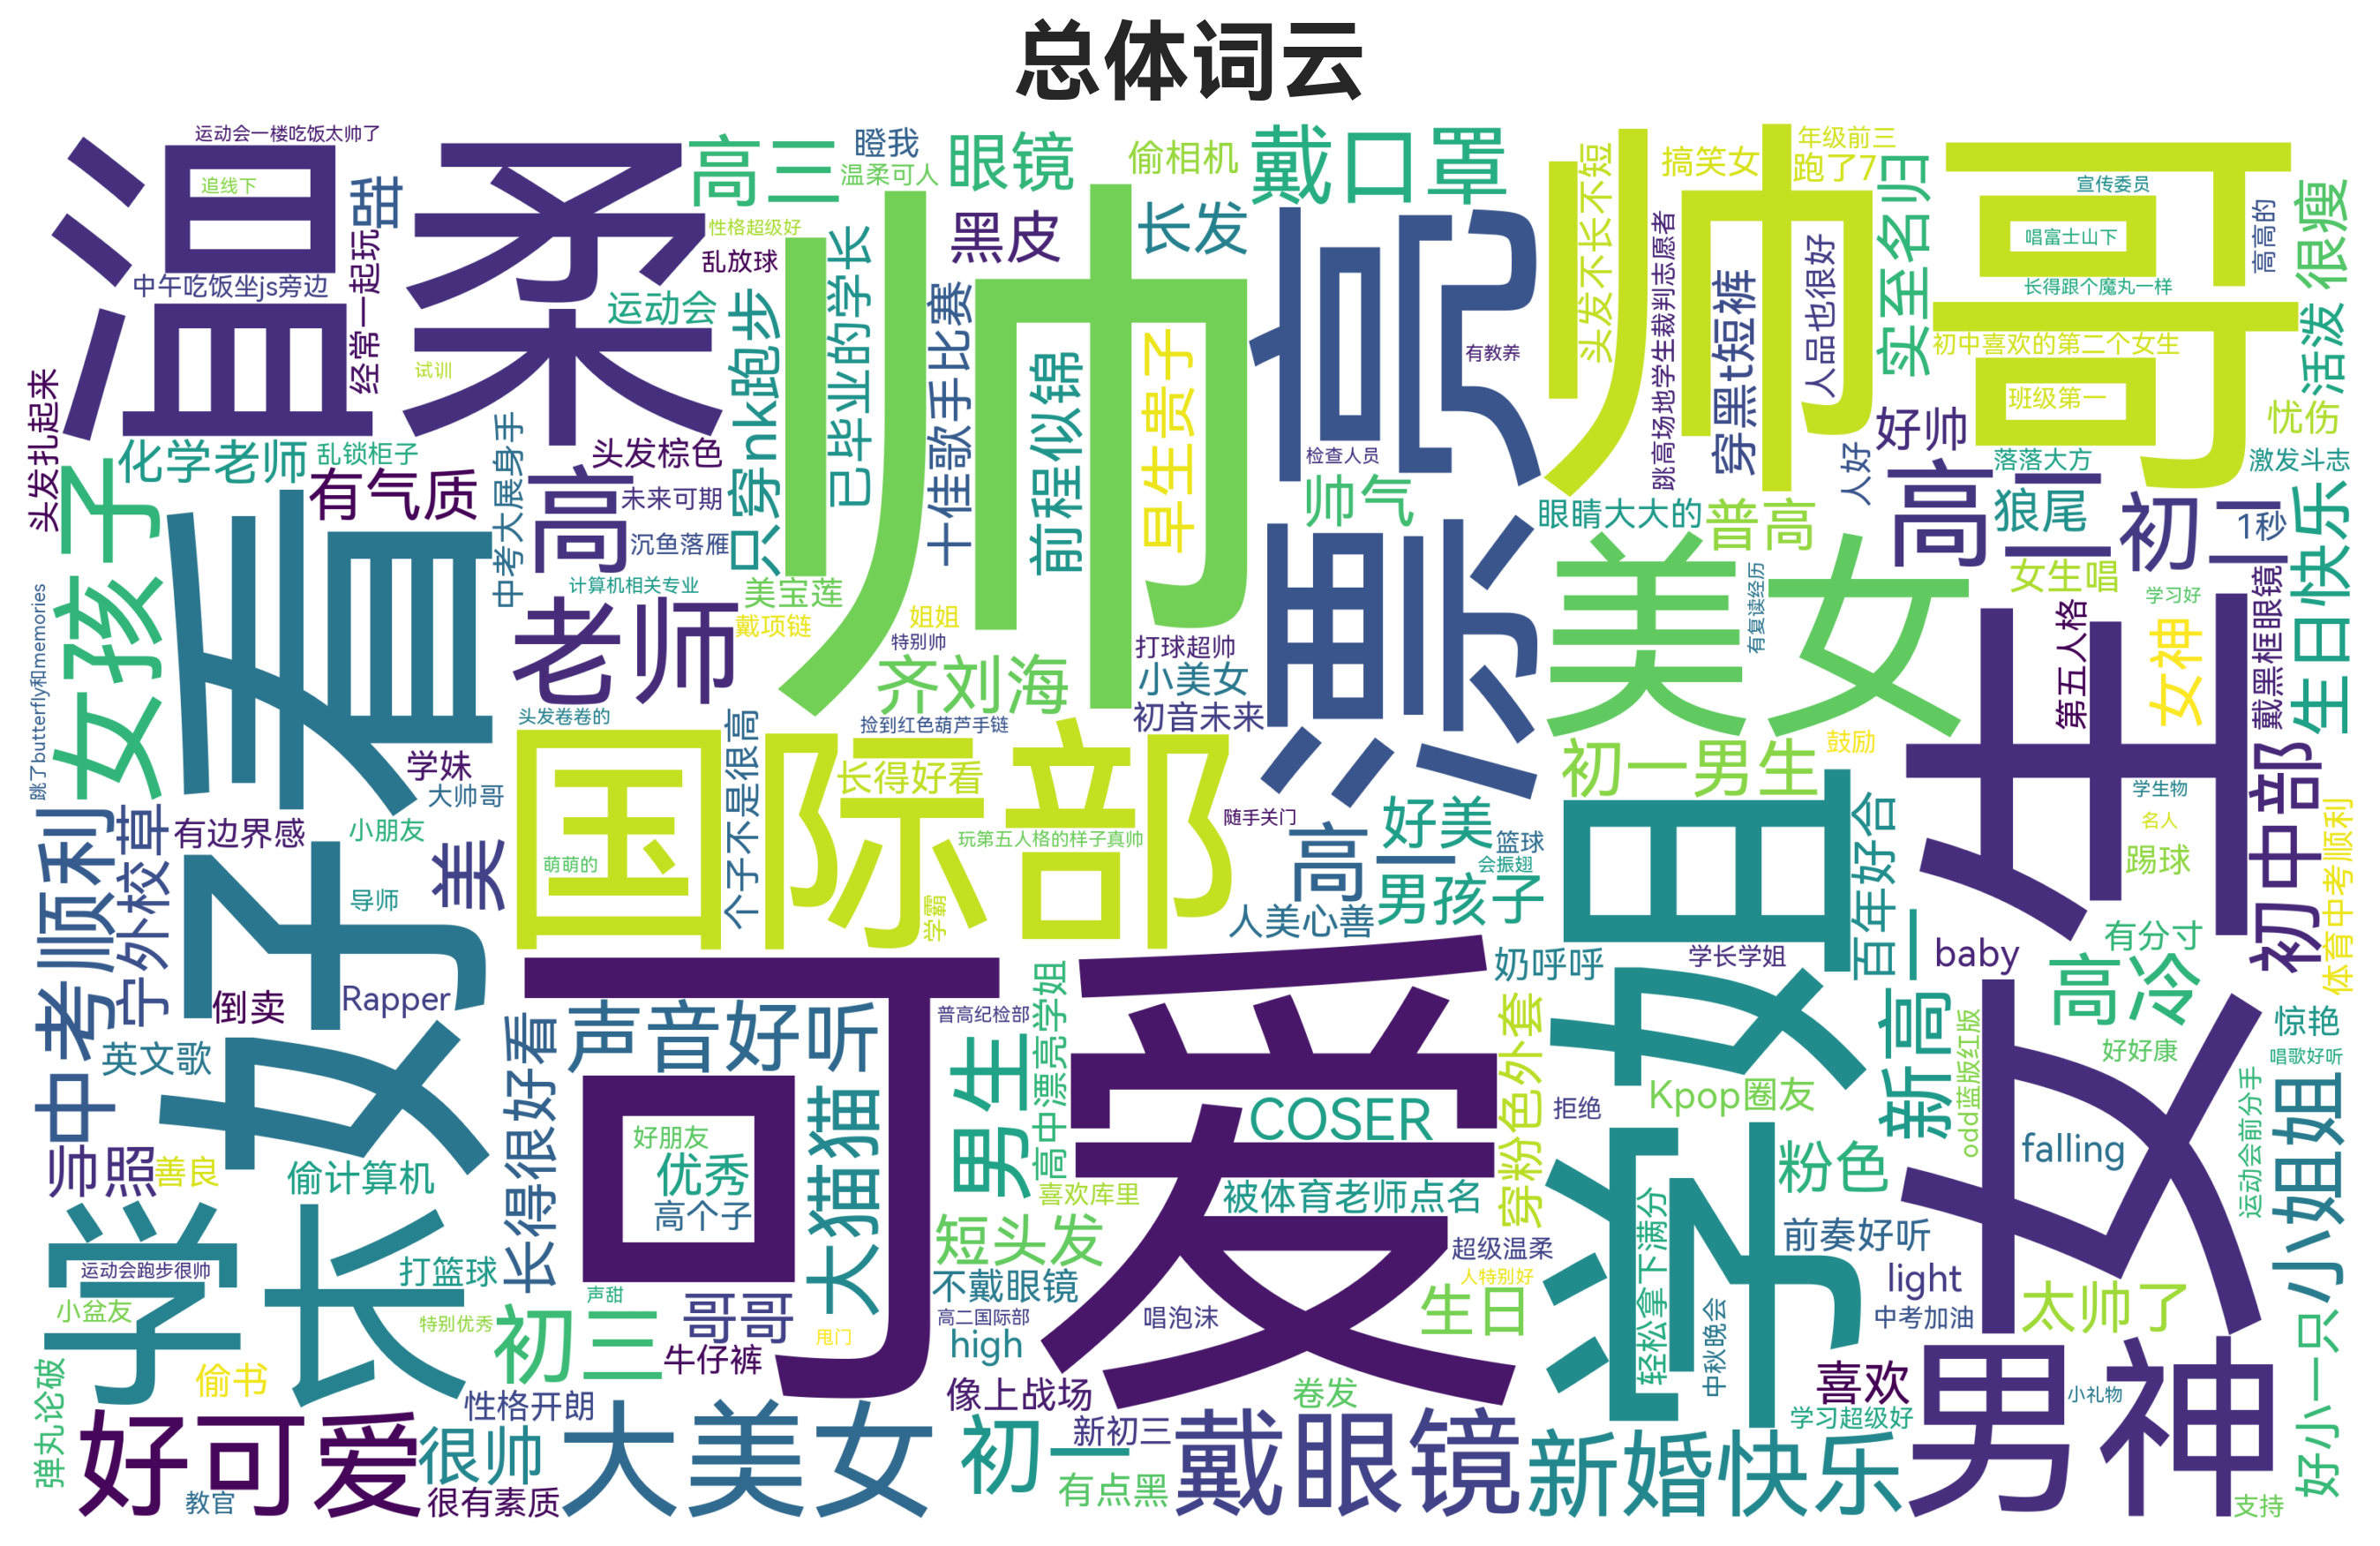

In [57]:
# 构建文本
total_wc_text = " ".join(full_data["description"].dropna().replace("无", ""))

generate_word_cloud(text=total_wc_text, title="总体词云", save_name="general_wordcloud")

##### 3.6.2 祝福内容词云

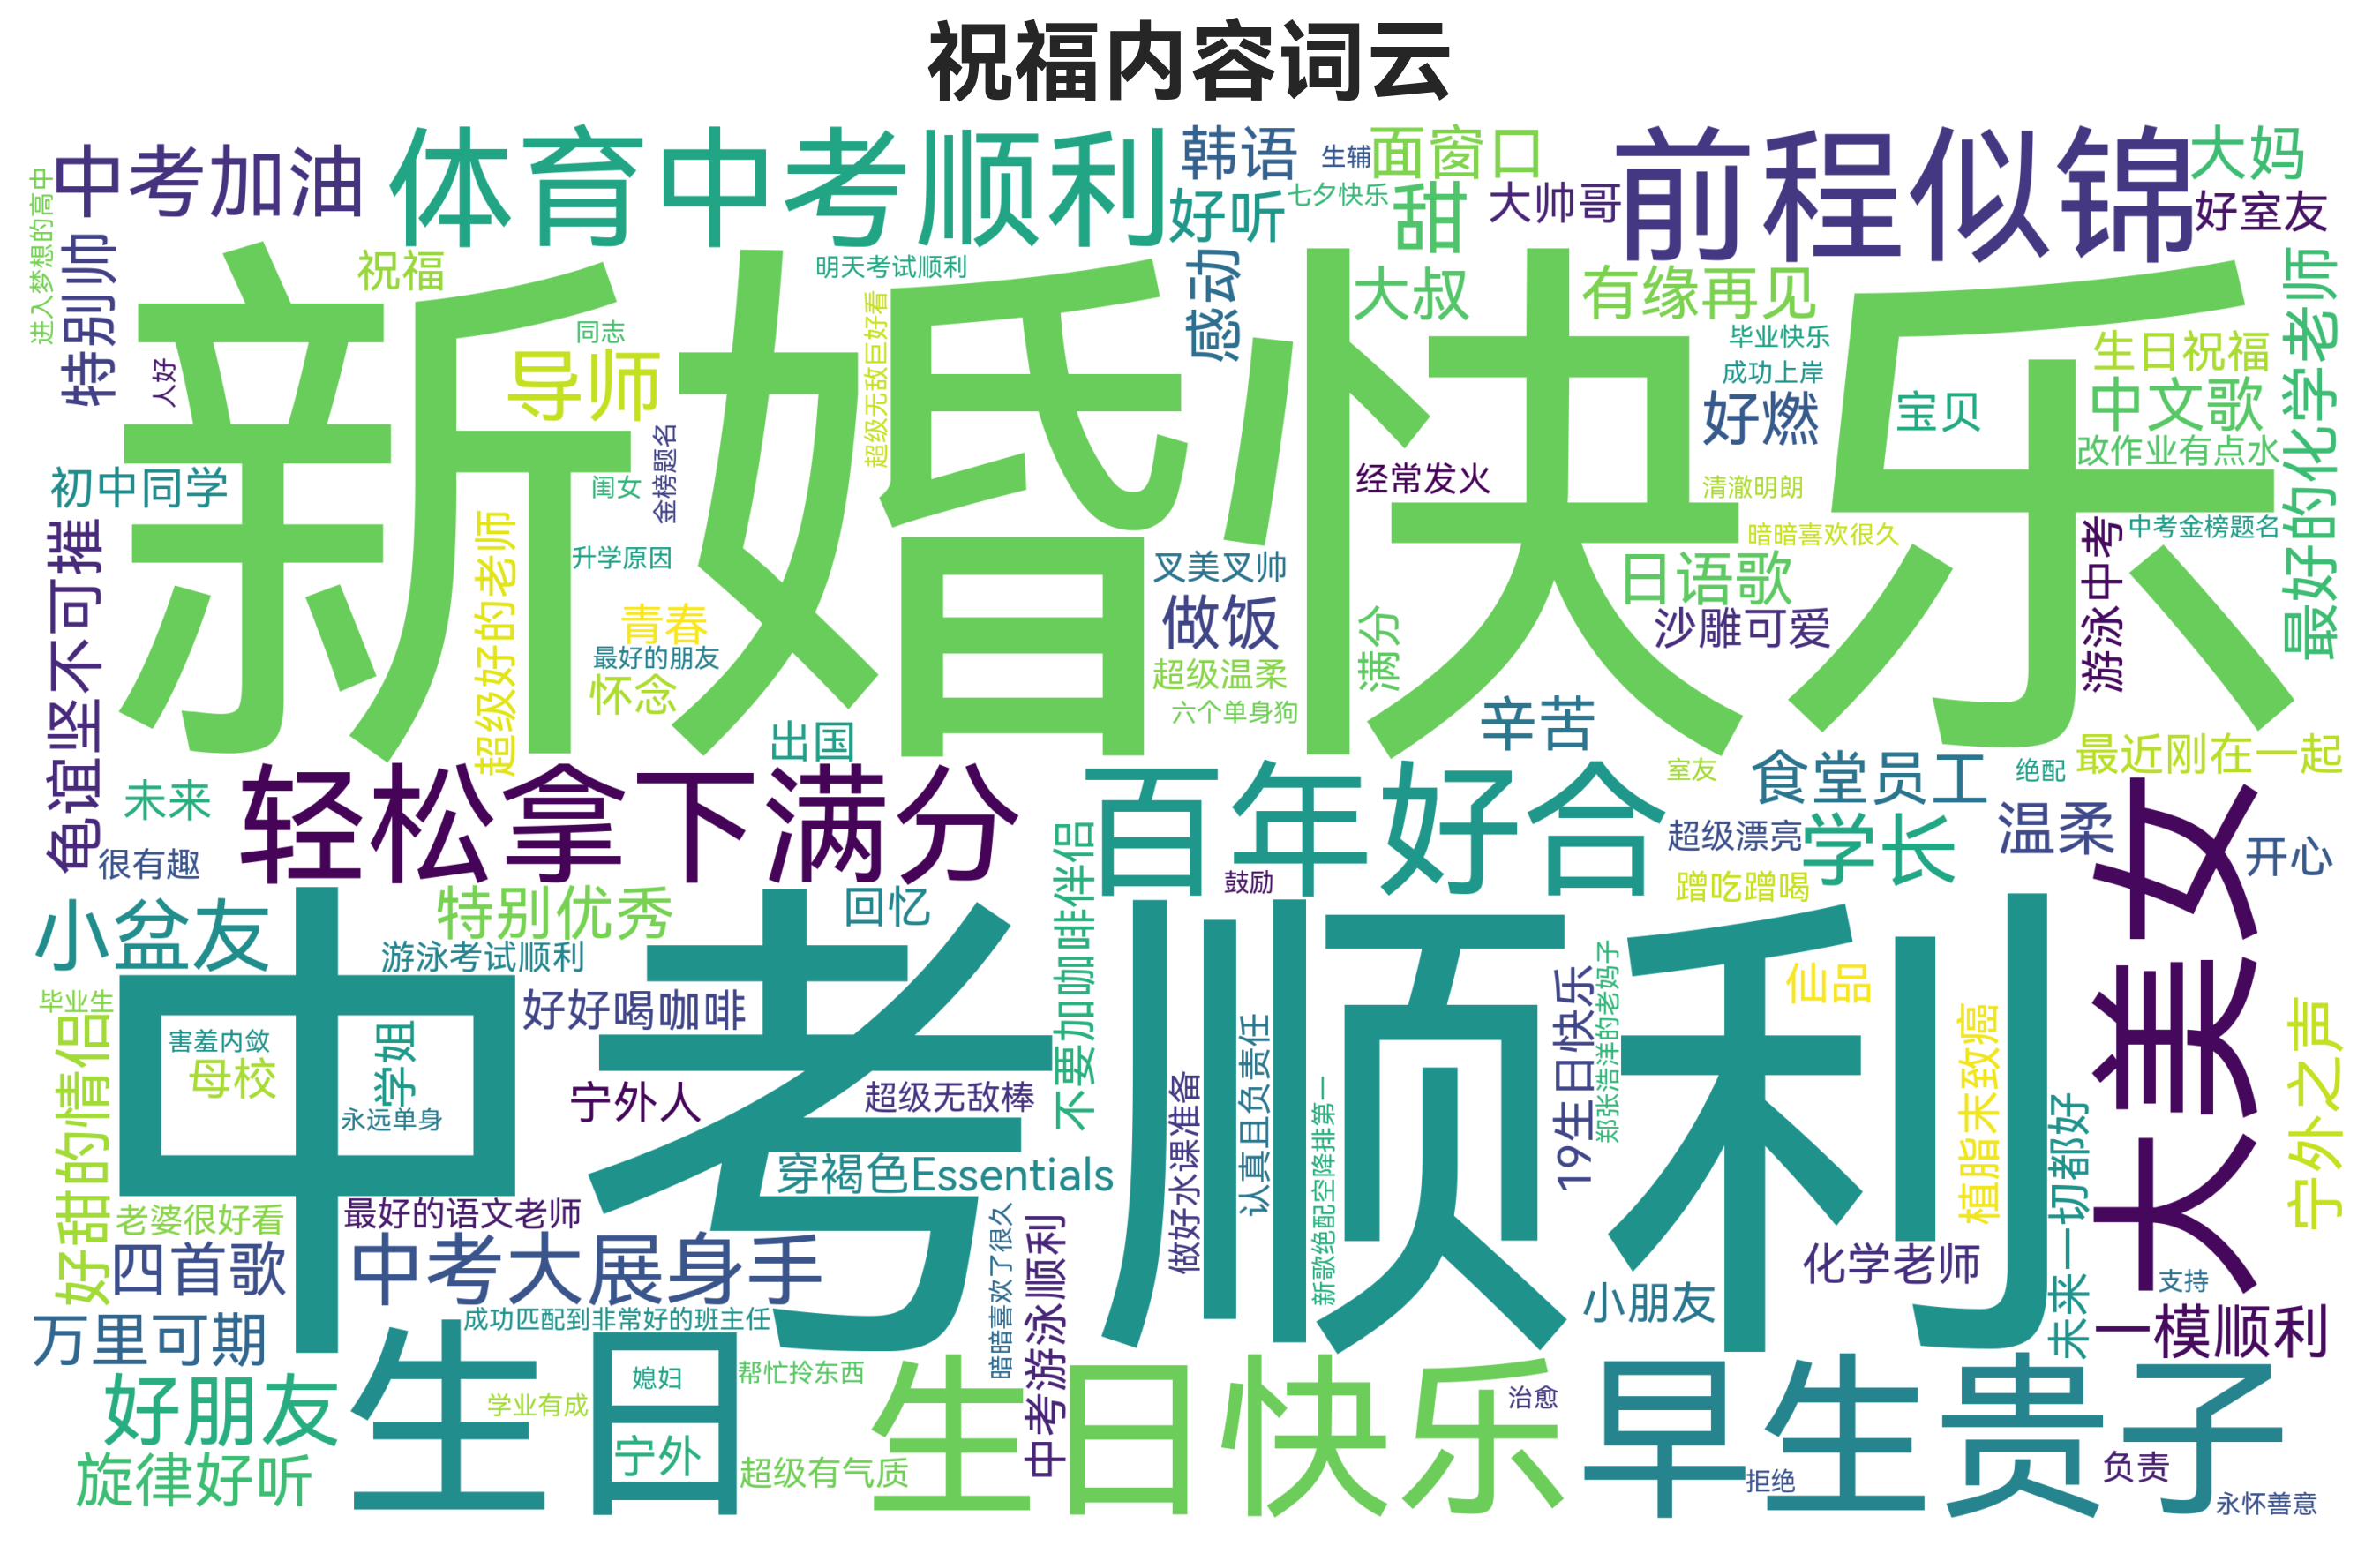

In [58]:
# 构建文本
wish_series = full_data.loc[full_data["purpose"]=="祝福", "description"]
wish_wc_text = " ".join(wish_series.dropna().replace("无", ""))

generate_word_cloud(text=wish_wc_text, title="祝福内容词云", save_name="wish_wordcloud")

##### 3.6.3 被表白对象词云

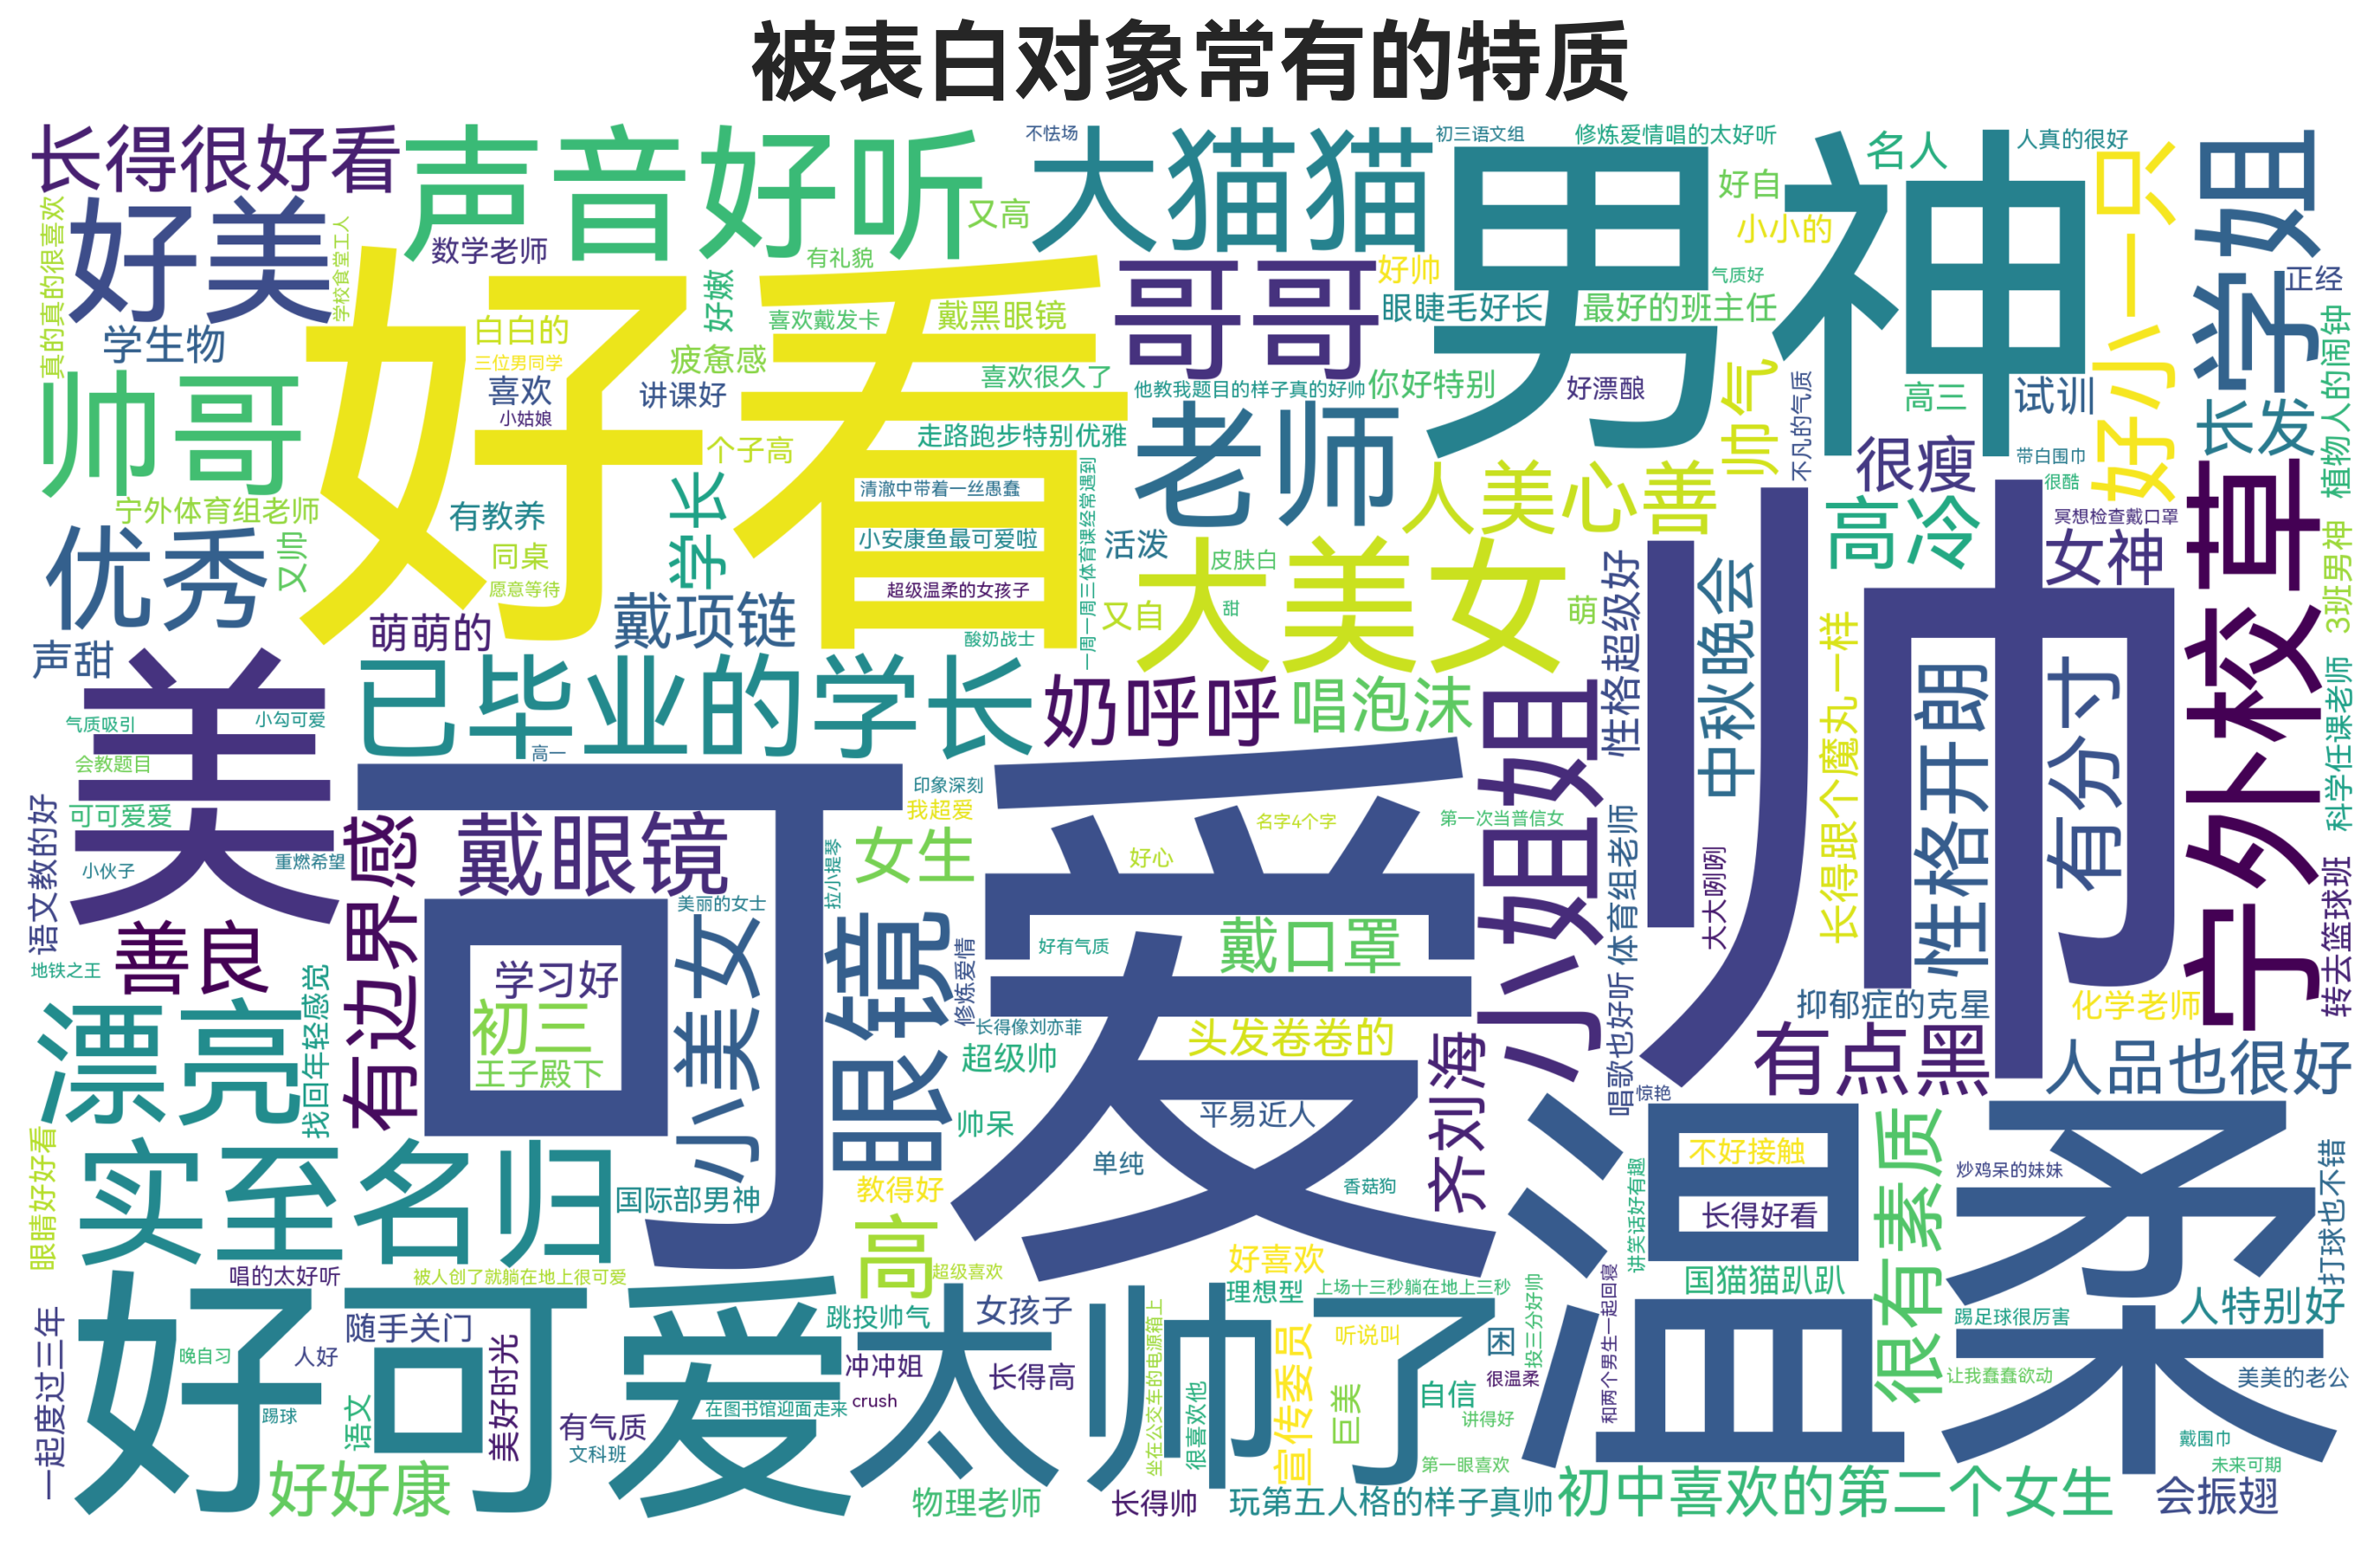

In [59]:
confession_data = full_data[full_data["purpose"] == "表白"]
confession_wc_text = " ".join(confession_data["description"].dropna().replace("无", ""))

generate_word_cloud(text=confession_wc_text, title="被表白对象常有的特质", save_name="confession_wordcloud")